# Sentinel Data Exploration


In [78]:
from pystac import Collection, MediaType, ItemCollection
from pystac_client import Client, CollectionClient
import numpy as np
import xarray as xr
import dask.array as da
from dask.distributed import Client as DaskClient

In [79]:
polygon_geojson = {
    "type": "Polygon",
    "coordinates": [
        [
            [18.03, 49.63],
            [18.27, 49.42],
            [18.70, 49.33],
            [19.20, 49.30],
            [19.55, 49.35],
            [19.90, 49.32],
            [20.30, 49.30],
            [20.70, 49.25],
            [21.00, 49.30],
            [21.05, 49.45],
            [20.95, 49.70],
            [20.70, 49.85],
            [20.30, 49.90],
            [19.90, 49.90],
            [19.55, 49.87],
            [19.20, 49.85],
            [18.80, 49.78],
            [18.40, 49.75],
            [18.10, 49.75],
            [18.03, 49.63]
        ]
    ]
}


In [80]:
eopf_stac_api_root_endpoint = "https://stac.core.eopf.eodc.eu/"
collection = "sentinel-2-l2a"
eopf_catalog = Client.open(url=eopf_stac_api_root_endpoint)

In [81]:
def fetch_catalogue_collection(collection_name: str) -> ItemCollection:
    search_result = eopf_catalog.search(
        collections=collection_name,
        bbox=(8.847198, 40.193395, 8.938865, 40.241895),
        #intersects=polygon_geojson,
        datetime='2024-05-01T00:00:00Z/2025-05-31T23:59:59.999999Z',
        max_items=10
    )
    return search_result.item_collection()

# Early Vegetation Stress Detection Using Sentinel-2 Time-Series Anomalies

We model normal vegetation behavior per pixel using rolling statistics of Sentinel-2 vegetation indices. Stress is detected as a significant deviation from recent conditions rather than absolute index thresholds. NDRE and MSI provide early signals of chlorophyll and moisture stress, while NDVI and EVI capture later biomass decline. A composite stress score integrates these indicators, enabling both early warning and severity assessment.

In [82]:
search_result_s2 = fetch_catalogue_collection(collection)
id_date_collection = [(item.id, item.datetime) for item in search_result_s2]

id_date_collection

[('S2B_MSIL2A_20250530T101559_N0511_R065_T32TMK_20250530T130924',
  datetime.datetime(2025, 5, 30, 10, 15, 59, 24000, tzinfo=tzutc())),
 ('S2A_MSIL2A_20250527T102041_N0511_R065_T32TMK_20250527T182102',
  datetime.datetime(2025, 5, 27, 10, 20, 41, 24000, tzinfo=tzutc())),
 ('S2B_MSIL2A_20250527T100559_N0511_R022_T32TMK_20250527T155229',
  datetime.datetime(2025, 5, 27, 10, 5, 59, 24000, tzinfo=tzutc())),
 ('S2C_MSIL2A_20250525T101621_N0511_R065_T32TMK_20250525T153015',
  datetime.datetime(2025, 5, 25, 10, 16, 21, 25000, tzinfo=tzutc())),
 ('S2A_MSIL2A_20250524T100701_N0511_R022_T32TMK_20250524T121311',
  datetime.datetime(2025, 5, 24, 10, 7, 1, 24000, tzinfo=tzutc())),
 ('S2C_MSIL2A_20250522T100611_N0511_R022_T32TMK_20250522T153214',
  datetime.datetime(2025, 5, 22, 10, 6, 11, 25000, tzinfo=tzutc())),
 ('S2A_MSIL2A_20250517T101701_N0511_R065_T32TMK_20250517T120915',
  datetime.datetime(2025, 5, 17, 10, 17, 1, 24000, tzinfo=tzutc())),
 ('S2B_MSIL2A_20250517T100559_N0511_R022_T32TMK_20250

In [83]:
c_sentinel2 = eopf_catalog.get_collection(collection)
items = c_sentinel2.get_items(*[item[0] for item in id_date_collection])
assets = [item.get_assets(media_type=MediaType.ZARR) for item in items]
cloud_storage_urls = [asset['product'].href for asset in assets]
cloud_storage_urls

['https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202505-s02msil2a/30/products/cpm_v256/S2B_MSIL2A_20250530T101559_N0511_R065_T32TMK_20250530T130924.zarr',
 'https://objectstore.eodc.eu:2222/e05ab01a9d56408d82ac32d69a5aae2a:202505-s02msil2a/27/products/cpm_v256/S2A_MSIL2A_20250527T102041_N0511_R065_T32TMK_20250527T182102.zarr',
 'https://objectstore.eodc.eu:2222/e05ab01a9d56408d82ac32d69a5aae2a:202505-s02msil2a/27/products/cpm_v256/S2B_MSIL2A_20250527T100559_N0511_R022_T32TMK_20250527T155229.zarr',
 'https://objectstore.eodc.eu:2222/e05ab01a9d56408d82ac32d69a5aae2a:202505-s02msil2a/25/products/cpm_v256/S2C_MSIL2A_20250525T101621_N0511_R065_T32TMK_20250525T153015.zarr',
 'https://objectstore.eodc.eu:2222/e05ab01a9d56408d82ac32d69a5aae2a:202505-s02msil2a/24/products/cpm_v256/S2A_MSIL2A_20250524T100701_N0511_R022_T32TMK_20250524T121311.zarr',
 'https://objectstore.eodc.eu:2222/e05ab01a9d56408d82ac32d69a5aae2a:202505-s02msil2a/22/products/cpm_v256/S2C_MSIL2A_20250522T100611_N0

In [90]:
datasets = []
for path in cloud_storage_urls[:10]:
    ds = xr.open_zarr(path,
                      group="/measurements/reflectance/r20m",
                      consolidated=True)
    t = [next(item[1]
              for item in id_date_collection if item[0] in path)]
    ds = ds.assign_coords(time=t)
    datasets.append(ds)
    # re-chunking
    ds = ds.chunk({
        "x": 512,
        "y": 512,
        "time": 1
    })


combined = xr.concat(datasets, dim="time", join="outer", data_vars='all')
combined = combined.persist()
combined

ServerDisconnectedError: Server disconnected

Normalized Difference Vegetation Index (NDVI) was used as a standard baseline for monitoring overall vegetation health.  It is widely recognized  for its sensitivity to  chlorophyll content and  photosynthetic activity. However, NDVI can saturate in densely vegetated areas and may be influenced
by soil reflectance.
The value range of the NDVI is -1 to 1. Negative values of NDVI (values approaching -1) correspond to water. Values close to zero (-0.1 to 0.1) generally correspond to barren areas of rock, sand, or snow. Low, positive values represent shrub
and grassland (approximately 0.2 to 0.4), while high values indicate temperate and tropical rainforests (values approaching 1).

The MSI is a reflectance measurement, sensitive to increases in leaf water content. The values of this index range from 0 to more than 3. The common range for green vegetation is 0.4 to 2.

Enhanced Vegetation Index values description: The range of values for EVI is -1 to 1, with healthy vegetation generally around 0.20 to 0.80.

<Axes: xlabel='time'>

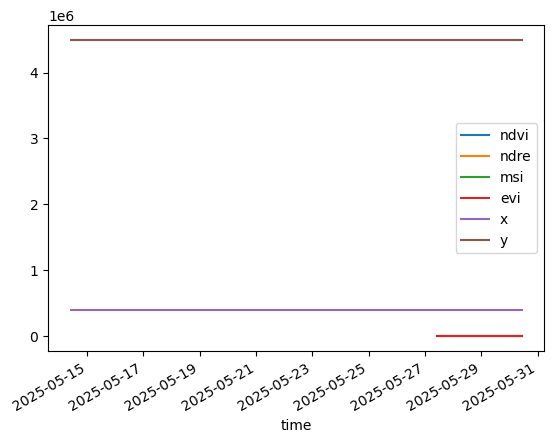

In [75]:
EPS = 1e-6

# NDRE = (NIR  RedEdge) / (NIR + RedEdge)
ndre = (combined['b8a'] - combined['b05']) / (combined['b8a'] + combined['b05'] + EPS)
# NDVI = (NIR - RED) / (NIR + RED)
ndvi = (combined['b8a'] - combined['b04']) / (combined['b8a'] + combined['b04'] + EPS)
# MSI = SWIR / NIR
msi = combined['b11'] / (combined['b8a'] + EPS)
# EVI = 2.5 * (NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1)
evi = 2.5 * (combined['b8a'] - combined['b04']) / (
        combined['b8a'] + 6 * combined['b04'] - 7.5 * combined['b02'] + 1 + EPS)

combined['ndre'] = ndre
combined['msi'] = msi
combined['evi'] = evi
combined['ndvi'] = ndvi
combined.sel(x=combined.x[100], y=combined.y[100])[
    ["ndvi", "ndre", "msi", "evi"]
].to_dataframe().plot()
#combined[["ndvi","ndre","msi","evi"]].mean(dim=["y","x"]).to_dataframe().plot()

- When z(NDVI) (greenness / biomass) goes down - vegetation losing greenness, which is late indicator and often reacts last.
- When z(NDRE) goes down it shows chlorophyll stress and serves as an early indicator.
- When MSI (moisture stress index) increases - means vegetation gets drier.
- EVI (dense vegetation) is helpful where NDVI cannot help us as much.

In [76]:
combined['ndre_z'] = -1 * (combined['ndre'] - combined['ndre'].mean(dim='time')) / combined['ndre'].std(dim='time')
combined['msi_z'] = (combined['msi'] - combined['msi'].mean(dim='time')) / combined['msi'].std(dim='time')
combined['evi_z'] = -1 * (combined['evi'] - combined['evi'].mean(dim='time')) / combined['evi'].std(dim='time')
combined['ndvi_z'] = -1 * (combined['ndvi'] - combined['ndvi'].mean(dim='time')) / combined['ndvi'].std(dim='time')
combined

<xarray.Dataset> Size: 43GB
Dimensions:  (time: 10, y: 5490, x: 5490)
Coordinates:
  * time     (time) datetime64[us] 80B 2025-05-30T10:15:59.024000 ... 2025-05...
  * y        (y) int64 44kB 4499990 4499970 4499950 ... 4390250 4390230 4390210
  * x        (x) int64 44kB 399970 399990 400010 400030 ... 509710 509730 509750
Data variables: (12/18)
    b01      (time, y, x) float64 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    b02      (time, y, x) float64 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    b03      (time, y, x) float64 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    b04      (time, y, x) float64 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    b05      (time, y, x) float64 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    b06      (time, y, x) float64 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    ...       ...
    evi      (time, y, x) float64 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    ndvi     (time, y, x) float64 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    ndre_z   (time, y, x) float64 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    msi_z    (time, y, x) float64 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    evi_z    (time, y, x) float64 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    ndvi_z   (time, y, x) float64 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>

Weights reflect how early / reliable each index is.

In [77]:
stress_score = (
        0.35 * combined['ndre_z'] +  # early chlorophyll stress
        0.30 * combined['msi_z'] +  # moisture stress
        0.20 * combined['ndvi_z'] +  # general decline
        0.15 * combined['evi_z']  # dense vegetation
)
#stress_score.isel(time=0).plot.imshow(vmin=-1, vmax=1, cmap='RdYlGn')
stress_score.isel(time=0).min().compute(), stress_score.isel(time=0).max().compute()

ServerDisconnectedError: Server disconnected

Early stress:
chlorophyll + moisture already bad,
greenness not yet collapsed

In [42]:
stress_level = xr.zeros_like(combined['ndvi_z'])

# severe stress = 2
stress_level = xr.where(
    (combined['ndvi_z'] > 2.0) & (combined['ndre_z'] > 2.0),
    2,
    stress_level
)

# early stress = 1 (only where not already severe)
stress_level = xr.where(
    (stress_level == 0) &
    (combined['ndre_z'] > 1.5) &
    (combined['msi_z'] > 1.5) &
    (combined['ndvi_z'] < 1.0),
    1,
    stress_level
)

combined['stress_level'] = stress_level

In [44]:
def slope(arr):
    mask = np.isfinite(arr)
    if mask.sum() < 2:
        return np.nan
    t = np.arange(len(arr))[mask]
    return np.polyfit(t, arr[mask], 1)[0]


ndvi_slope = combined['ndvi'].rolling(time=5).reduce(slope)
confirmed_stress = (combined['stress_level'] == 2) & (ndvi_slope < -0.02)

TypeError: slope() got an unexpected keyword argument 'axis'

C:\Users\dmitr\miniconda3\envs\climate_analysis\Lib\site-packages\dask\array\numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
C:\Users\dmitr\miniconda3\envs\climate_analysis\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


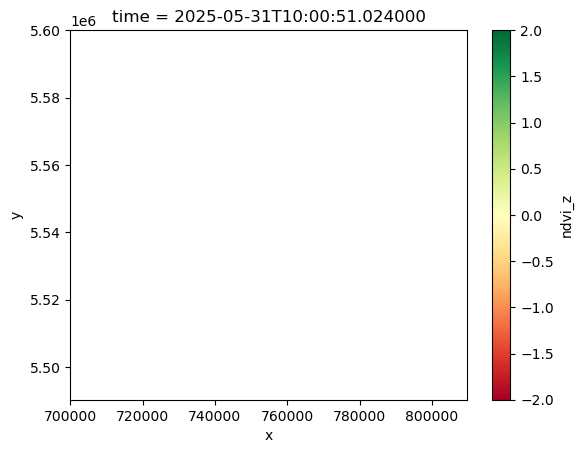

In [45]:
combined['ndvi_z'].isel(time=0).plot.imshow(vmin=-2, vmax=2, cmap='RdYlGn')

In [50]:
def retrieve_zarr_urls(collection_name: str, ids: list[str]) -> list[str]:
    c = eopf_catalog.get_collection(collection_name)
    items = c.get_items(*ids)
    assets = [item.get_assets(media_type=MediaType.ZARR) for item in items]
    cloud_storage_urls = [asset['product'].href for asset in assets]
    return cloud_storage_urls